In [26]:
import time
import sys
from collections import defaultdict
from typing import Any, Callable, Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scipy.stats as sps
import seaborn as sns
import statsmodels
import statsmodels.api as sm


from IPython.display import HTML, clear_output, display
from tqdm import tqdm
from tqdm.auto import tqdm as auto_tqdm

from sktime.split import ExpandingWindowSplitter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsforecast import models as sf_models
from statsforecast.models import SimpleExponentialSmoothing, SimpleExponentialSmoothingOptimized

# from statsmodels.tsa.holtwinters import ExponentialSmoothing, Holt, SimpleExpSmoothing
# from statsmodels.tsa.seasonal import STL, seasonal_decompose
# from statsmodels.tsa.stattools import adfuller, kpss
# from torch import nn
# from torch.utils.data import DataLoader, Dataset, random_split
# from tsfresh import extract_features, select_features
# from tsfresh.feature_extraction import settings
# from tsfresh.utilities.dataframe_functions import impute, roll_time_series

# import pmdarima as pm
# import tsfresh
# from catboost import CatBoostRegressor
# from prophet import Prophet

from pylab import rcParams

# Visualization setup
sns.set(font_scale=1.3, palette="Set2")
rcParams['figure.figsize'] = 15, 7
%matplotlib inline

In [27]:
sys.path.append('/Users/ivannovikov/Documents/Code/gm-inputs/Sber-Conditional')

%load_ext autoreload
%autoreload 2

from utils.models import DummyConditionalModel, VARModel
from utils.vis import plot_error_matrix, plot_model_pred, calc_average_error, visualize_ts
from utils.interface import cross_validate_model, calc_avg_error, build_error_matrix, build_short_error_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


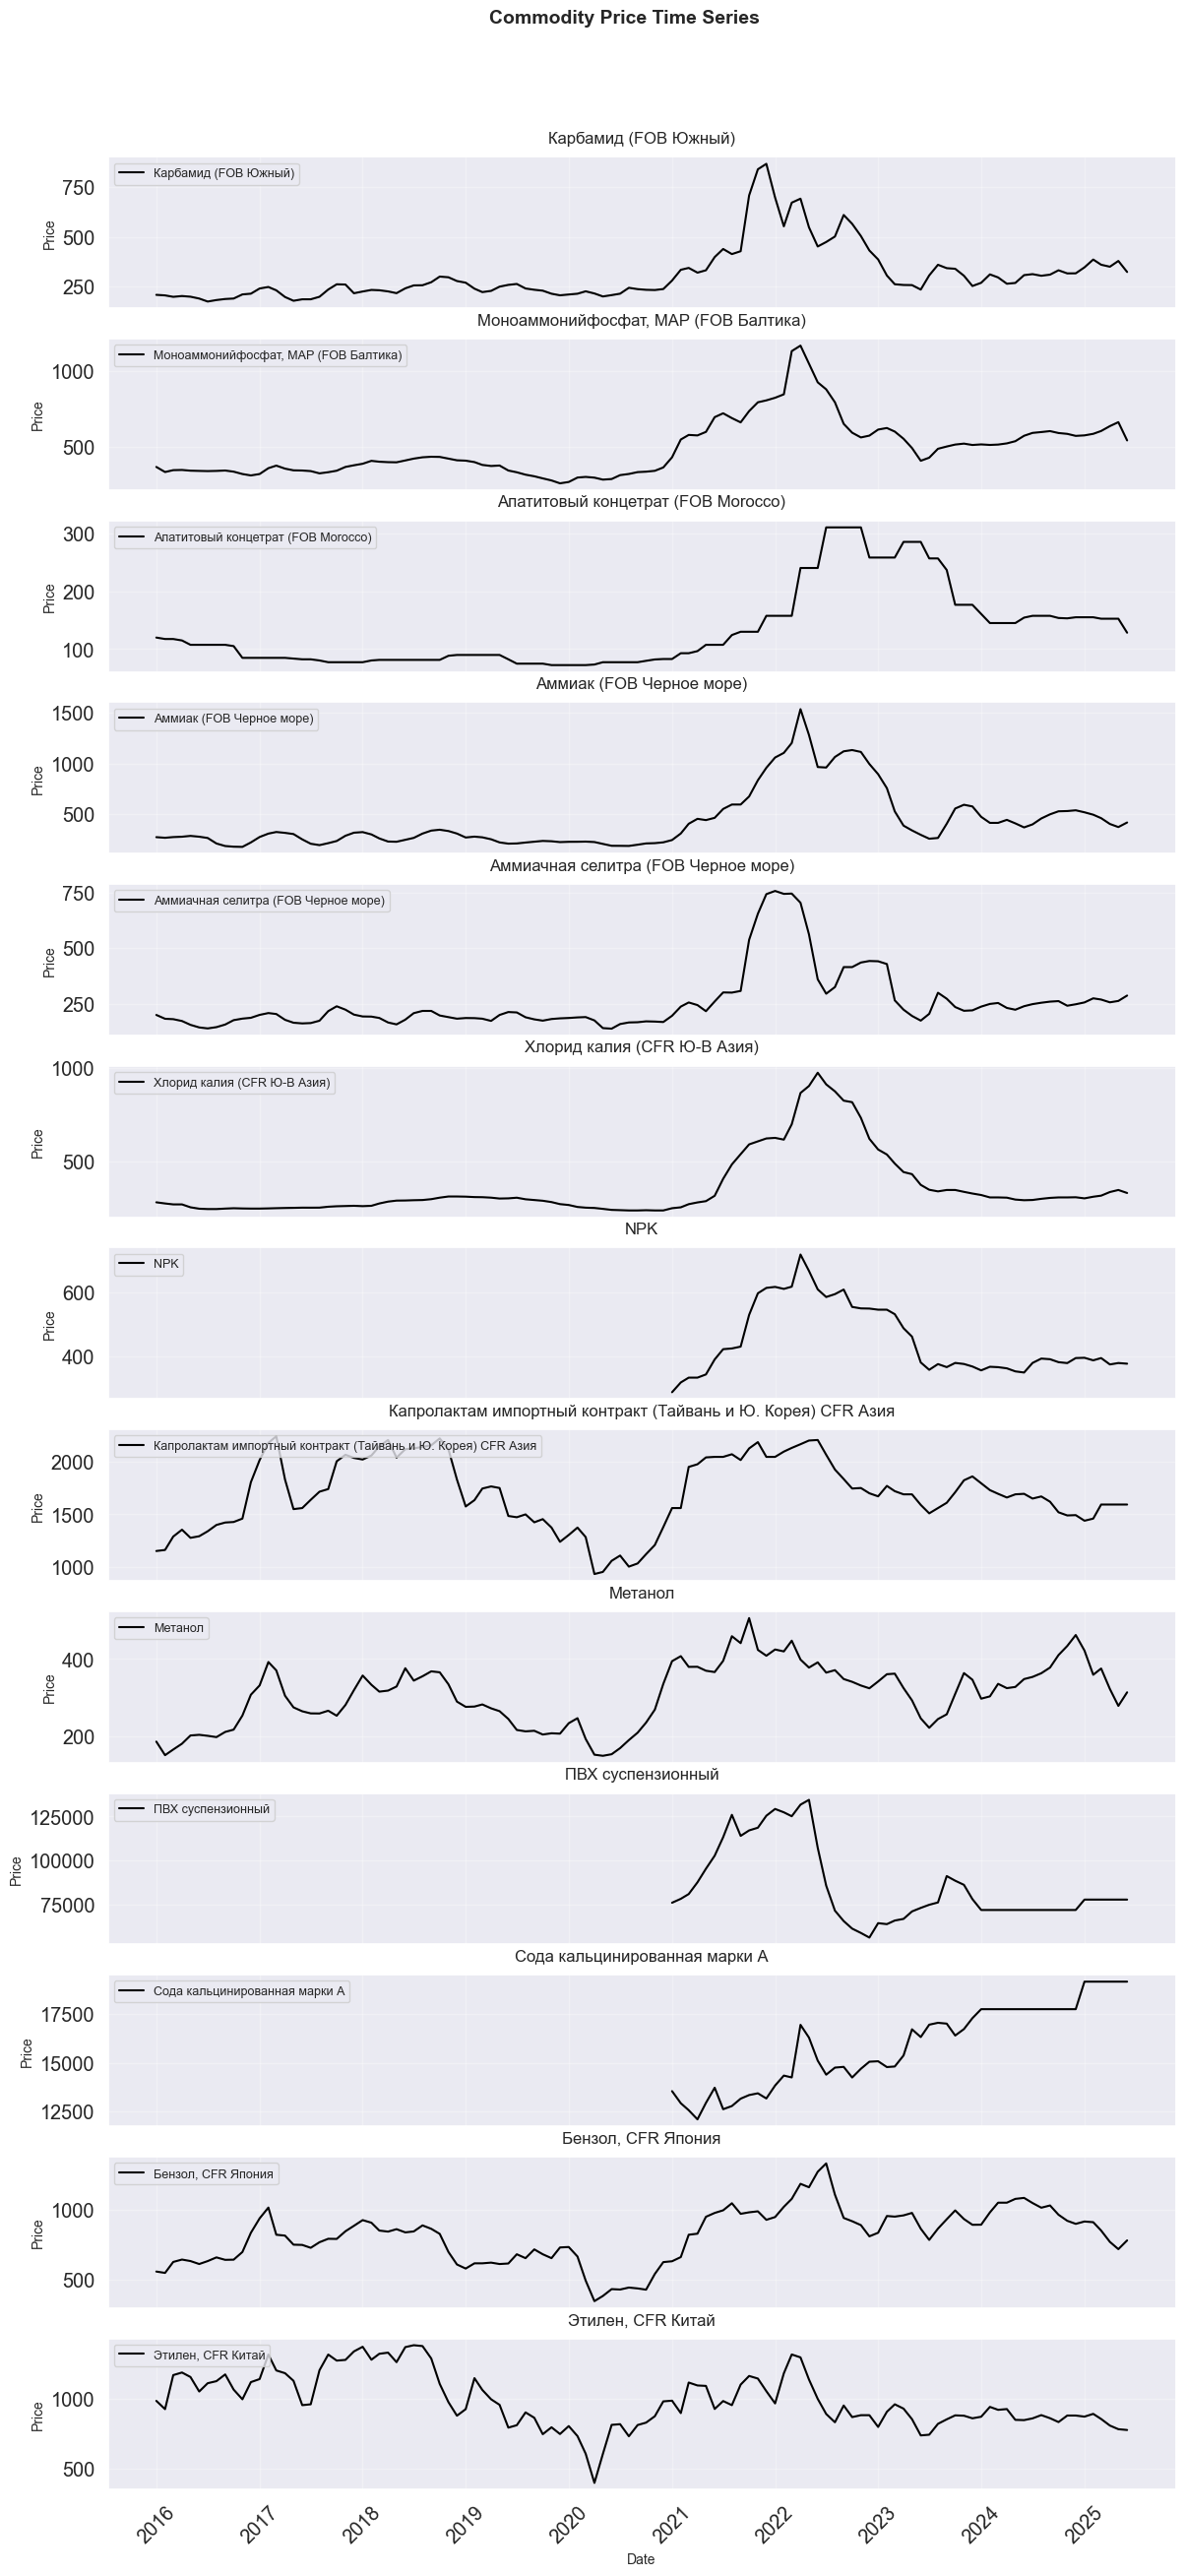

In [ ]:
df = pd.read_csv("/Users/ivannovikov/Documents/Code/gm-inputs/Sber-Conditional/Data/chemicals.csv", index_col=0)
df.index = pd.to_datetime(df.index)
df = df.drop(columns=['Unnamed: 8', 'Unnamed: 9'])
visualize_ts(df, df.columns, figsize=(14, 30))

df = df.drop(columns=['NPK', 'ПВХ суспензионный', 'Бензол, CFR Япония'])

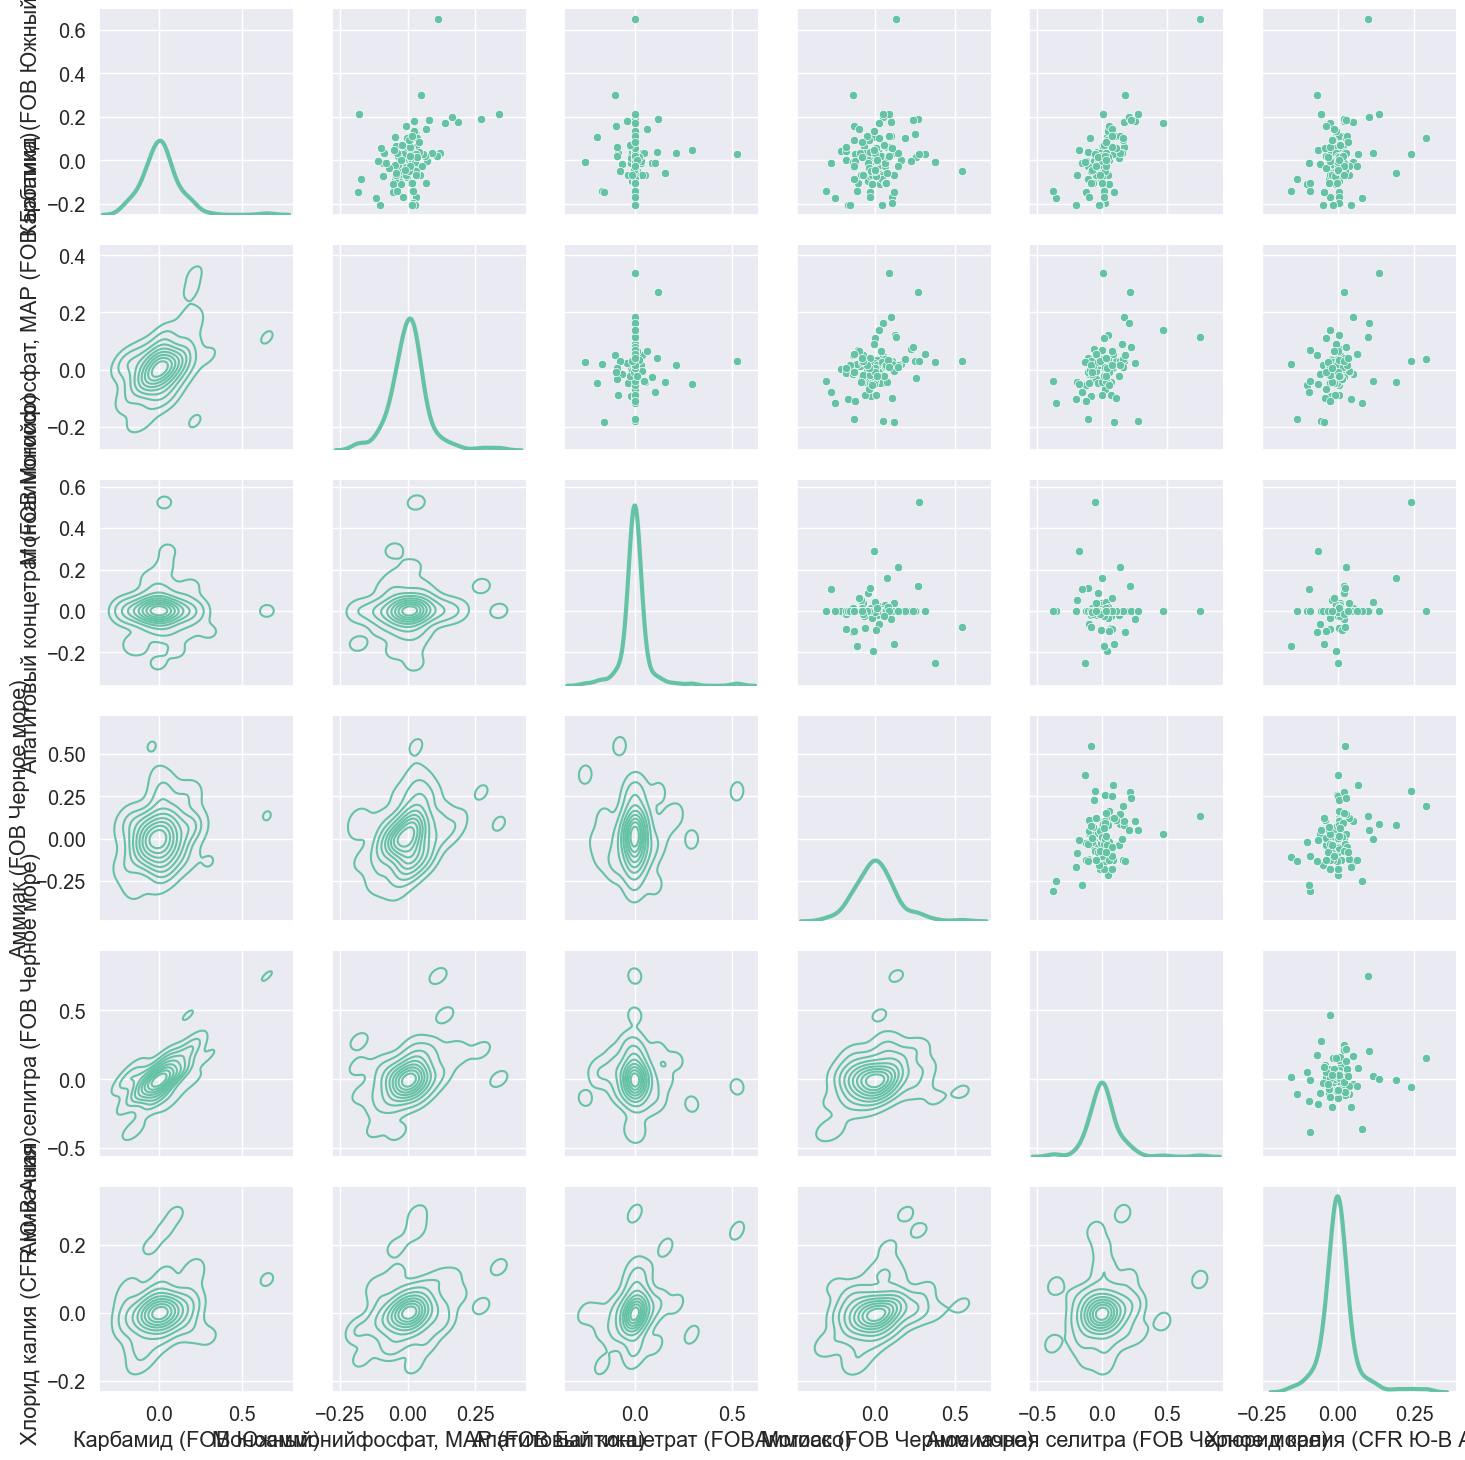

In [ ]:
# log_rets_df = np.log(df).diff()
log_rets_df = df.pct_change()

g = sns.PairGrid(log_rets_df[cols[:6]])
g.map_upper(sns.scatterplot)
g.map_lower(sns.kdeplot)
g.map_diag(sns.kdeplot, lw=3, legend=False)

### There is no significant correlation but some of the series seem to cointegrate
### DTW transformation should be helpful